In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.stats import linregress
import seaborn as sns

In [2]:
pd.options.display.max_columns = None

In [3]:
df = pd.read_csv('../data/nova_pay_combined.csv')

In [4]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [5]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [6]:
df["datetime"] = pd.to_datetime(df.timestamp, errors = "coerce")

In [7]:
df.loc[df.ip_address.isnull(), ["customer_id", "datetime", "amount_usd", "fee", "ip_address", "ip_country", "kyc_tier", "device_trust_score"]].isnull().sum()

customer_id             0
datetime                0
amount_usd            305
fee                   295
ip_address            305
ip_country            301
kyc_tier              300
device_trust_score    295
dtype: int64

In [8]:
df.home_country.unique()

<StringArray>
['US', 'CA', 'UK', ' UK  ', ' US  ', 'unknown', ' CA  ']
Length: 7, dtype: str

In [9]:
df.home_country = df.home_country.str.strip()

In [10]:
df.home_country.value_counts()

home_country
US         8008
UK         2132
CA         1228
unknown      32
Name: count, dtype: int64

In [14]:
customers_home_country = df.groupby(by = ["customer_id"]).aggregate({"home_country": pd.Series.nunique})
customers_home_country

,home_country
customer_id,
0006f893-10a8-4235-831b-fcae1e3f0140,1
00147b79-11ed-4f8f-a3af-651778b78dd3,1
00668d83-6f9f-4401-9a0f-04f94140abb6,1
00957a15-945f-4bfb-b5fc-d867cbaee95d,1
00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1
...,...
feabfbce-0104-4f21-ba98-991e86b21774,1
feec7b74-5e30-4ac2-9aca-b7724f6fc179,1
ff82d8ff-a00f-4be3-b7a7-4adae615e36c,1


In [15]:
customers_home_country.home_country.unique()

array([1, 2])

In [16]:
customers_home_country.loc[customers_home_country.home_country > 1]

,home_country
customer_id,
23d9943d-57b1-42eb-9ef2-05eed7fd1957,2
402cccc9-28de-45b3-9af7-cc5302aa1f93,2
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2
70a93d26-8e3a-4179-900c-a4a7a74d08e5,2
7bd5200c-5d19-44f0-9afe-8b339a05366b,2
7e5600c3-9d8b-488d-b761-5b530fa49f27,2
af8ca4c4-8703-4c55-b66c-2b76cd70040d,2


In [19]:
customers = customers_home_country.loc[customers_home_country.home_country > 1].index.tolist()

In [21]:
df.loc[df.customer_id.isin(customers)].groupby(by = ["customer_id"]).aggregate({"home_country":pd.Series.unique})

,home_country
customer_id,
23d9943d-57b1-42eb-9ef2-05eed7fd1957,"[UK, unknown]"
402cccc9-28de-45b3-9af7-cc5302aa1f93,"[US, unknown]"
67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,"[CA, unknown]"
6d0d9b27-fa26-45f8-93b1-2df29d182d9c,"[US, unknown]"
7041b9c1-3719-4ca8-9a6b-811b47cea6c0,"[UK, unknown]"
70a93d26-8e3a-4179-900c-a4a7a74d08e5,"[US, unknown]"
7bd5200c-5d19-44f0-9afe-8b339a05366b,"[US, unknown]"
7e5600c3-9d8b-488d-b761-5b530fa49f27,"[US, unknown]"
af8ca4c4-8703-4c55-b66c-2b76cd70040d,"[US, unknown]"


In [32]:
home_country = df.loc[df.customer_id.isin(customers)].groupby(by = ["customer_id"]).aggregate({"home_country":pd.Series.unique}).home_country.apply(lambda x: x[0]).to_dict()
home_country

{'23d9943d-57b1-42eb-9ef2-05eed7fd1957': 'UK',
 '402cccc9-28de-45b3-9af7-cc5302aa1f93': 'US',
 '67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad': 'CA',
 '6d0d9b27-fa26-45f8-93b1-2df29d182d9c': 'US',
 '7041b9c1-3719-4ca8-9a6b-811b47cea6c0': 'UK',
 '70a93d26-8e3a-4179-900c-a4a7a74d08e5': 'US',
 '7bd5200c-5d19-44f0-9afe-8b339a05366b': 'US',
 '7e5600c3-9d8b-488d-b761-5b530fa49f27': 'US',
 'af8ca4c4-8703-4c55-b66c-2b76cd70040d': 'US',
 'd71c91b4-fee8-4104-9856-a5c6109a62e3': 'US',
 'f7531a78-8bbe-4a85-b1e8-a0650edddc72': 'US'}

In [37]:
df.loc[(df.customer_id.isin(customers)) & (df.home_country == "unknown"), "home_country"] = df.loc[(df.customer_id.isin(customers)) & (df.home_country == "unknown"), ["customer_id", "home_country"]].apply(lambda x: home_country.get(x.customer_id), axis = 1)

In [38]:
df.home_country.value_counts()

home_country
US    8031
UK    2139
CA    1230
Name: count, dtype: int64

In [41]:
df.ip_country.unique()

<StringArray>
['US', 'CA', nan, 'UK', ' US  ', 'NAN', 'unknown', ' CA  ', ' UK  ', ' nan  ']
Length: 10, dtype: str

In [42]:
df.ip_country = df.ip_country.str.strip().apply(lambda x: np.nan if x in ["NAN", "nan"] else x)

In [43]:
df.ip_country.value_counts()

ip_country
US         6897
UK         2425
CA         1741
unknown      33
Name: count, dtype: int64

In [45]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country != df.ip_country),
    "location_mismatch"
].mean()

np.float64(0.9830693610049154)

In [46]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country == df.ip_country) &
    (df.location_mismatch),
    ["customer_id", "datetime", "home_country", "ip_country", "location_mismatch"]
]

,customer_id,datetime,home_country,ip_country,location_mismatch
10254,d741ff3a-5bf0-45da-b6a6-8bca86774141,2024-01-05 09:42:49.573611+00:00,CA,CA,True
10272,a4e38294-55f1-443a-9a89-9ff2a2952c47,2024-01-15 10:14:32.573611+00:00,US,US,True
10390,87a3670e-dc21-4366-acdf-fb40c2e649ab,2024-04-14 09:20:21.573611+00:00,US,US,True
10458,dc1ec03d-b327-43af-82bd-2461ea087936,2024-05-18 09:10:31.573611+00:00,US,US,True
10466,80b7a4b7-4ab0-4101-9dd4-ea8f6e42571f,2024-05-21 11:42:49.573611+00:00,UK,UK,True
10473,0e1720d3-173a-4ca7-a889-28289c0e1a26,2024-05-28 17:02:22.573611+00:00,US,US,True
10586,290f0121-9e7d-4953-aaad-fbb024ac749c,2024-08-08 16:25:30.573611+00:00,US,US,True
10627,5edff35f-c02b-4e1c-9c0f-58dd65613368,2024-09-04 12:32:43.573611+00:00,US,US,True
10700,3ca06712-688e-453d-ae03-032fdd1771b4,2024-10-07 10:39:57.573611+00:00,UK,UK,True
10728,a2c0e41c-7886-4193-98b2-04790a6f7495,2024-10-24 14:57:03.573611+00:00,US,US,True


In [47]:
customers = df.loc[
    (df.ip_country.notnull()) &
    (df.home_country == df.ip_country) &
    (df.location_mismatch),
    "customer_id"
].tolist()

In [48]:
df.loc[df.customer_id.isin(customers), "customer_id"].value_counts()

customer_id
d741ff3a-5bf0-45da-b6a6-8bca86774141    1
a4e38294-55f1-443a-9a89-9ff2a2952c47    1
87a3670e-dc21-4366-acdf-fb40c2e649ab    1
dc1ec03d-b327-43af-82bd-2461ea087936    1
80b7a4b7-4ab0-4101-9dd4-ea8f6e42571f    1
0e1720d3-173a-4ca7-a889-28289c0e1a26    1
290f0121-9e7d-4953-aaad-fbb024ac749c    1
5edff35f-c02b-4e1c-9c0f-58dd65613368    1
3ca06712-688e-453d-ae03-032fdd1771b4    1
a2c0e41c-7886-4193-98b2-04790a6f7495    1
f175f7de-153c-4f6b-82a5-84f7fc865fef    1
e7333eb0-38e5-47fa-a108-9d90b351a093    1
3460e415-fbac-4b12-b694-bfd9d8892d26    1
9fb6f540-2b58-4377-b2ac-ee1a8800f721    1
5d1f9bb6-b9dd-4ec0-ac96-f1439bdb76a3    1
462848c6-8102-4179-8332-879a6ece388a    1
1e5e4b4d-a168-48f9-8243-a57422dae0b0    1
a1d6add2-f3f9-4286-8eca-60b3f05fc916    1
c5600ee4-32a9-4689-8a6a-86e5946616a8    1
14b0135b-714f-4b2d-9ca1-23760c535558    1
Name: count, dtype: int64

In [49]:
df.loc[(df.ip_country.notnull()) & (df.home_country == df.ip_country) & (df.location_mismatch), "location_mismatch"] = False

In [50]:
df.loc[
    (df.ip_country.notnull()) &
    (df.home_country != df.ip_country) &
    (~df.location_mismatch),
    ["customer_id", "datetime", "home_country", "ip_country", "location_mismatch"]
]

,customer_id,datetime,home_country,ip_country,location_mismatch
712,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-12-23 10:09:56.468549+00:00,UK,unknown,False
933,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-01-16 13:46:08.468549+00:00,US,unknown,False
1232,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-02-14 22:28:21.468549+00:00,US,unknown,False
1290,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-02-22 05:17:57.468549+00:00,US,unknown,False
1623,402cccc9-28de-45b3-9af7-cc5302aa1f93,2023-04-01 12:50:20.468549+00:00,US,unknown,False
2145,d71c91b4-fee8-4104-9856-a5c6109a62e3,2023-05-30 07:25:30.468549+00:00,US,unknown,False
2313,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2023-06-18 06:22:18.468549+00:00,US,unknown,False
2572,d71c91b4-fee8-4104-9856-a5c6109a62e3,2023-07-14 03:58:42.468549+00:00,US,unknown,False
3172,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2023-09-21 22:04:58.468549+00:00,UK,unknown,False
3185,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2023-09-23 19:03:22.468549+00:00,US,unknown,False


In [54]:
df.loc[(df.ip_country.notnull()) & (df.home_country != df.ip_country) & (~df.location_mismatch), "ip_country"] = df.loc[(df.ip_country.notnull()) & (df.home_country != df.ip_country) & (~df.location_mismatch), "home_country"]

In [56]:
df.ip_country.value_counts()

ip_country
US         6921
UK         2431
CA         1742
unknown       2
Name: count, dtype: int64

In [58]:
df.loc[df.ip_country == "unknown", ["customer_id", "datetime", "home_country", "ip_address", "ip_country", "location_mismatch", "is_fraud"]]

,customer_id,datetime,home_country,ip_address,ip_country,location_mismatch,is_fraud
8529,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2025-04-28 14:44:40.468549+00:00,CA,7.187.51.25,unknown,True,0
9140,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-07-02 21:57:48.468549+00:00,US,99.148.50.57,unknown,True,0


In [60]:
df.kyc_tier.unique()

<StringArray>
[   'standard',    'enhanced',         'low', ' standard  ',           nan,
     'standrd', ' enhanced  ',    'STANDARD',         'NAN',     'unknown',
     'enhancd',      ' low  ',    'ENHANCED',         'LOW',      ' nan  ']
Length: 15, dtype: str

In [66]:
df.kyc_tier.isnull().sum()

np.int64(300)

In [70]:
df.kyc_tier = df.kyc_tier.str.strip().str.lower().str.replace({"standrd": "standard", "enhancd": "enhanced"}).replace({"nan": np.nan})

In [72]:
df.source_currency.unique()

<StringArray>
['USD', 'CAD', 'GBP']
Length: 3, dtype: str

In [73]:
df.amount_src.dtype

<StringDtype(storage='python', na_value=nan)>

In [76]:
df.amount_src = df.amount_src.str.replace(",", "").astype(float)

In [79]:
df.loc[df.amount_src < 0, ["source_currency", "amount_src", "amount_usd"]]

,source_currency,amount_src,amount_usd
328,USD,-37.08,37.08
564,USD,-176.92,176.92
576,USD,-702.71,702.71
596,USD,-230.36,230.36
602,CAD,-203.83,150.83
...,...,...,...
9894,GBP,-186.29,232.86
9965,USD,-211.64,211.64
10001,USD,-320.40,320.40
10006,CAD,-272.59,201.72


In [84]:
df.loc[(df.amount_src < 0) & (df.amount_usd.notnull()), "amount_usd"].apply(lambda x: x >= 0).mean()

np.float64(1.0)

In [88]:
df.loc[df.amount_src < 0, "amount_src"] = df.loc[df.amount_src < 0, "amount_src"].abs()

In [92]:
df.loc[(df.source_currency == "USD") & (df.amount_usd.notnull()), ["amount_src", "amount_usd"]].apply(lambda x: x.amount_src == x.amount_usd, axis = 1).mean()

np.float64(1.0)

In [97]:
df.loc[
    (df.amount_usd.notnull()) &
    (df.source_currency == "CAD"),
    ["amount_src", "amount_usd"]
].apply(lambda x: round(x.amount_src / x.amount_usd, 2), axis = 1).value_counts()

1.35    1207
Name: count, dtype: int64

In [98]:
df.loc[
    (df.amount_usd.notnull()) &
    (df.source_currency == "GBP"),
    ["amount_src", "amount_usd"]
].apply(lambda x: round(x.amount_src / x.amount_usd, 2), axis = 1).value_counts()

0.8    2072
Name: count, dtype: int64

In [99]:
def convert_currency(currency: str, value: float) -> float:
    
    conversion = {
        "USD": 1.0,
        "GBP": 0.8,
        "CAD": 1.35
    }

    rate = conversion.get(currency)
    return round(value / rate, 2)

In [102]:
df.loc[df.amount_usd.isnull(), ["source_currency", "amount_src"]]

,source_currency,amount_src
13,GBP,322.24
49,USD,255.06
151,USD,502.97
163,CAD,100.87
168,USD,265.30
...,...,...
10054,USD,9993.94
10082,USD,414.29
10093,USD,125.75
10142,GBP,83.96


In [104]:
df.loc[df.amount_usd.isnull(), "amount_usd"] = df.loc[df.amount_usd.isnull(), ["source_currency", "amount_src"]].apply(lambda x: convert_currency(x.source_currency, x.amount_src), axis = 1)

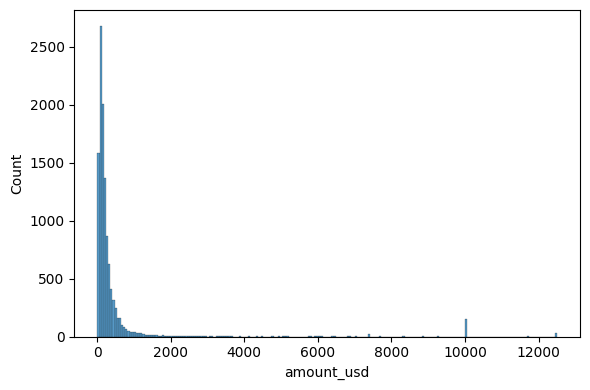

In [174]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.histplot(df.amount_usd, ax = ax)

plt.tight_layout()
plt.show()

In [181]:
df.loc[(df.fee.notnull()) & (df.fee > 500), "fee"].value_counts()

fee
9999.99    103
Name: count, dtype: int64

In [170]:
df.amount_usd.max(), df.fee.quantile(0.99)

(np.float64(12498.58), np.float64(152.03879999999995))

In [226]:
df.loc[df.txn_velocity_1h < 0].shape[0]

204

In [225]:
df.loc[df.device_trust_score < 0].shape[0]

204

In [235]:
df.loc[df.ip_risk_score == 1.2].shape[0]

204

In [236]:
df.loc[
    (df.ip_risk_score == 1.2) &
    (df.txn_velocity_1h < 0) &
    (df.device_trust_score < 0),
    ["datetime", "customer_id", "home_country", "ip_address", "ip_country", "location_mismatch", "ip_risk_score", "txn_velocity_1h", "device_trust_score", "fee"]
]

,datetime,customer_id,home_country,ip_address,ip_country,location_mismatch,ip_risk_score,txn_velocity_1h,device_trust_score,fee
51,2022-10-09 08:57:10.468549+00:00,402cccc9-28de-45b3-9af7-cc5302aa1f93,US,71.133.231.78,CA,True,1.2,-1,-0.1,-1.00
60,2022-10-10 12:06:38.468549+00:00,d71c91b4-fee8-4104-9856-a5c6109a62e3,US,102.188.190.205,US,False,1.2,-1,-0.1,-1.00
78,2022-10-12 08:33:52.468549+00:00,70a93d26-8e3a-4179-900c-a4a7a74d08e5,US,154.171.88.114,US,False,1.2,-1,-0.1,-1.00
225,2022-10-28 19:29:13.468549+00:00,7bd5200c-5d19-44f0-9afe-8b339a05366b,US,51.190.9.19,US,False,1.2,-1,-0.1,-1.00
328,2022-11-10 03:14:05.468549+00:00,d71c91b4-fee8-4104-9856-a5c6109a62e3,US,223.51.189.238,US,False,1.2,-1,-0.1,9999.99
...,...,...,...,...,...,...,...,...,...,...
9982,2025-09-30 21:52:28.468549+00:00,d71c91b4-fee8-4104-9856-a5c6109a62e3,US,195.144.215.27,US,False,1.2,-1,-0.1,-1.00
10001,2023-08-29 10:22:29.468549+00:00,af8ca4c4-8703-4c55-b66c-2b76cd70040d,US,214.69.54.29,US,False,1.2,-1,-0.1,9999.99
10006,2024-09-14 09:31:14.468549+00:00,140d2232-ee97-4934-81aa-9e5c323d7c6f,CA,86.94.79.160,CA,False,1.2,-1,-0.1,9999.99
10131,2024-02-07 07:06:42.468549+00:00,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,UK,74.138.217.202,UK,False,1.2,-1,-0.1,-1.00


In [229]:
df.loc[(df.txn_velocity_1h < 0) & (df.device_trust_score < 0), ["fee", "txn_velocity_1h", "device_trust_score"]]

,fee,txn_velocity_1h,device_trust_score
51,-1.00,-1,-0.1
60,-1.00,-1,-0.1
78,-1.00,-1,-0.1
225,-1.00,-1,-0.1
328,9999.99,-1,-0.1
...,...,...,...
9982,-1.00,-1,-0.1
10001,9999.99,-1,-0.1
10006,9999.99,-1,-0.1
10131,-1.00,-1,-0.1


In [230]:
df.loc[(df.fee.notnull()) & (df.fee < 0)]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,datetime
51,37acea94-2ecf-4cba-bf3a-a2b418a02300,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-09 08:57:10.468549+00:00,US,USD,EUR,web,67.19,67.19,-1.0,0.925926,16e4b1b1-a590-45cf-b154-6b8edbcf0dbd,False,71.133.231.78,CA,True,1.2,standard,263,-0.1,0,0.223,-1,0,0.0,0,2022-10-09 08:57:10.468549+00:00
60,c42328f0-a715-472d-b261-61edc7ae5dd0,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-10-10 12:06:38.468549+00:00,US,USD,USD,mobile,190.42,190.42,-1.0,1.000000,bad152b7-36e0-4613-820d-bec469406d0c,False,102.188.190.205,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.0,0,2022-10-10 12:06:38.468549+00:00
78,1b5ca03f-8c61-47fc-9005-69f9f6e80641,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-12 08:33:52.468549+00:00,US,USD,INR,web,130.13,130.13,-1.0,83.333333,1116845f-d9e9-4194-bf8c-9ab64d4dcaf8,False,154.171.88.114,US,False,1.2,enhanced,257,-0.1,0,0.257,-1,0,0.0,0,2022-10-12 08:33:52.468549+00:00
225,d62b3fb6-ed94-45ca-9024-2fe6ecf85ff1,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-28 19:29:13.468549+00:00,US,USD,GBP,ATM,81.19,81.19,-1.0,0.800000,0fb34cef-8f16-4c2f-97b4-acff71c1e81a,False,51.190.9.19,US,False,1.2,standard,147,-0.1,0,0.391,-1,1,0.0,0,2022-10-28 19:29:13.468549+00:00
350,e7545ae0-8f77-4988-84c9-27ab8c6230df,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-11-12 23:11:53.468549+00:00,US,USD,CAD,web,316.74,316.74,-1.0,1.351351,94a091c6-1038-415e-8159-bb2be277778d,False,113.154.10.249,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.0,0,2022-11-12 23:11:53.468549+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9854,93c6edfa-bf83-4cbd-9b8d-e9b14db86280,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2025-09-17 17:52:12.468549+00:00,US,USD,INR,web,156.30,156.30,-1.0,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,226.152.80.38,US,False,1.2,enhanced,257,-0.1,0,0.257,-1,0,0.0,0,2025-09-17 17:52:12.468549+00:00
9860,283ff19c-54cb-4941-93b2-95515868dae3,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2025-09-18 04:25:41.468549+00:00,US,USD,CNY,mobile,284.58,284.58,-1.0,7.142857,7d766a27-4665-4341-8d5e-45a56f9cf55a,False,117.89.104.21,CA,True,1.2,enhanced,367,-0.1,0,0.176,-1,0,0.0,0,2025-09-18 04:25:41.468549+00:00
9972,c7e0ddea-114b-4d9a-81eb-a921e4e35157,23d9943d-57b1-42eb-9ef2-05eed7fd1957,2025-09-29 13:43:45.468549+00:00,UK,GBP,GBP,mobile,172.35,215.44,-1.0,1.000000,1f81d60c-25b5-495c-a49c-b59a3aa4fb3a,False,87.147.209.216,UK,False,1.2,standard,718,-0.1,0,0.169,-1,0,0.0,0,2025-09-29 13:43:45.468549+00:00
9982,bac7754a-4335-4d89-8ca6-f6530377c936,d71c91b4-fee8-4104-9856-a5c6109a62e3,2025-09-30 21:52:28.468549+00:00,US,USD,INR,mobile,164.16,164.16,-1.0,83.333333,ecf86eb0-ca14-4e1c-905c-3134d0a3a647,False,195.144.215.27,US,False,1.2,standard,298,-0.1,0,0.166,-1,0,0.0,0,2025-09-30 21:52:28.468549+00:00


In [199]:
fee_df = df.loc[(df.fee.notnull()) & (df.amount_usd <= 2_000) & (df.fee <= 500), ["fee", "amount_usd", "source_currency"]]
fee_df.reset_index(drop = True, inplace = True)
fee_df.head()

,fee,amount_usd,source_currency
0,4.25,278.19,USD
1,4.24,154.29,CAD
2,2.70,160.33,USD
3,2.22,59.41,USD
4,3.61,200.96,USD


In [200]:
fee_mean, fee_std = fee_df.fee.mean(), fee_df.fee.std()
amount_mean, amount_std = fee_df.amount_usd.mean(), fee_df.amount_usd.std()

In [201]:
y = (fee_df.fee - fee_mean) / fee_std
X = (fee_df.amount_usd - amount_mean) / amount_std

In [202]:
lr = linregress(X.values, y.values)

In [203]:
lr.intercept, lr.slope

(np.float64(1.6837897619582885e-16), np.float64(0.9574381116742995))

In [204]:
y_hat = (X * lr.slope) + lr.intercept

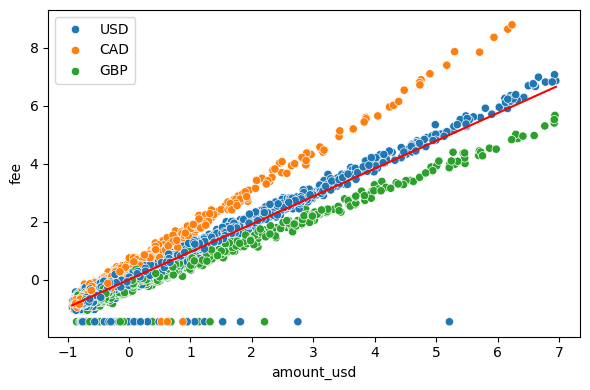

In [209]:
fig, ax = plt.subplots(figsize = (6, 4))

sns.scatterplot(x = X, y = y, hue = fee_df.source_currency.tolist(), ax = ax)
sns.lineplot(x = X, y = y_hat, color = "r", ax = ax)

plt.tight_layout()
plt.show()

In [213]:
y[(X > 5) & (y < 0)]

8359   -1.452799
Name: fee, dtype: float64

In [217]:
idx = y[y <= -1.452799].index

In [220]:
fee_df.loc[idx]

,fee,amount_usd,source_currency
47,-1.0,67.19,USD
55,-1.0,190.42,USD
73,-1.0,130.13,USD
210,-1.0,81.19,USD
325,-1.0,316.74,USD
...,...,...,...
9271,-1.0,156.30,USD
9277,-1.0,284.58,USD
9379,-1.0,215.44,GBP
9388,-1.0,164.16,USD


In [219]:
fee_df.loc[idx, "fee"].value_counts()

fee
-1.0    98
Name: count, dtype: int64

In [142]:
y_hat

0       -0.000538
1        0.001106
2        0.001026
3        0.002366
4        0.000487
           ...   
10785   -0.000446
10786   -0.002122
10787    0.001139
10788    0.002119
10789   -0.012961
Name: amount_usd, Length: 10790, dtype: float64

In [125]:
df.loc[df.amount_usd > max_, "amount_usd"]

11       9998.43
15       9991.85
53       7398.00
88       9993.40
147      7395.25
          ...   
11323    2468.29
11334    4112.77
11342    6053.90
11365    9237.34
11374    3503.36
Name: amount_usd, Length: 288, dtype: float64

In [116]:
df.loc[df.fee.isnull(), "amount_usd"].quantile(0.25)

np.float64(86.715)

In [105]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                     0
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   304
location_mismatch              0
ip_risk_score                  0
kyc_tier                     303
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
datetime                      61
dtype: int64

In [8]:
df.loc[df.timestamp.isnull(), :]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,...,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,...,0.353,standard,298,0.336,0,0.166,0,0,0.00,0
578,b371fb34-0744-4b90-b33d-237b95b0cd52,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,INR,mobile,251.95,251.95,5.68,...,0.424,enhanced,367,0.939,0,0.176,0,0,0.00,0
1003,3e96cacd-3722-469f-95c1-6dce5ba73aa6,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,web,51.22,51.22,1.23,...,0.569,standard,147,0.401,0,0.391,0,1,0.00,0
1325,c646535b-dd51-4d09-b155-e603bbafdc7e,70a93d26-8e3a-4179-900c-a4a7a74d08e5,NaN,US,USD,USD,mobile,9993.44,9993.44,150.77,...,0.398,enhanced,257,0.894,0,0.257,0,1,0.00,0
1501,f340c84f-8021-483c-9a7e-b1fae29a3859,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,GBP,web,165.8,165.80,3.62,...,0.337,enhanced,367,0.939,0,0.176,0,0,0.00,0
1522,fcf3662d-6acd-4303-902f-0a46cefda734,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,mobile,90.11,90.11,2.42,...,0.268,standard,147,0.551,0,0.391,0,0,0.00,0
1780,c99dc8d7-24b9-4527-93dc-29cb6711bbe6,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,NaN,UK,GBP,PHP,web,41.1,51.37,2.13,...,0.234,standard,4,0.892,0,0.407,0,0,0.00,1
2053,bf335e6c-a6bc-4fa3-96ed-516d8d7ca793,af8ca4c4-8703-4c55-b66c-2b76cd70040d,NaN,US,USD,PHP,mobile,126.75,126.75,3.55,...,0.257,standard,1018,0.934,0,0.087,0,0,0.10,0
2112,611e6035-5389-45bd-a467-6aaf83493a0a,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,INR,mobile,56.95,56.95,1.78,...,0.304,standard,263,0.522,0,0.223,0,1,0.00,0


In [11]:
df.source_currency.value_counts()

source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [12]:
df.dest_currency.value_counts()

dest_currency
NGN    1474
USD    1328
INR    1325
CNY    1324
PHP    1314
GBP    1296
CAD    1282
EUR    1196
MXN     861
Name: count, dtype: int64

In [14]:
df.loc[(df.source_currency == "USD") & (df.dest_currency == "USD"), :].head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
11,43a11314-6420-4e23-b0a8-69d5f010da86,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-04 22:54:28.468549+00:00,US,USD,USD,mobile,9998.43,9998.43,151.63,1.0,4bb9533a-117f-455a-9e69-a484a77a7176,False,79.129.58.248,US,False,0.254,standard,1018,0.934,0,0.087,0,0,0.0,0
25,8b701ec2-f0d3-432d-bb4b-7e1745bef34f,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-06 09:34:57.468549+00:00,US,USD,USD,mobile,121.06,121.06,3.04,1.0,162dcfa8-d2e4-4449-9b0d-7d56fd981991,False,155.92.229.247,US,False,0.163,standard,147,0.551,0,0.391,0,0,0.0,0
32,1823877a-cc28-4333-929a-5523a0d20120,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-07 08:31:21.468549+00:00,US,USD,USD,mobile,232.66,232.66,4.31,1.0,33919fa4-5dbb-41b0-a895-ec15ab2c10f1,False,62.78.115.149,US,False,0.271,standard,263,0.522,0,0.223,0,0,0.0,0
34,8fe20fa1-61c3-4eae-a3ed-160718e0b209,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-07 09:07:42.468549+00:00,US,USD,USD,mobile,61.27,61.27,1.79,1.0,3deb41ac-8c17-4c96-b1e9-24c67ea0de90,False,218.149.36.208,US,False,0.223,enhanced,367,0.939,0,0.176,0,0,0.0,0
44,f38d1c57-3dd4-433e-a3cd-c07f4ec25304,af8ca4c4-8703-4c55-b66c-2b76cd70040d,2022-10-08 08:19:24.468549+00:00,US,USD,USD,web,254.28,254.28,4.22,1.0,ff15b1b0-c6a7-4bd1-8ba7-a892d37c8d02,True,56.105.104.32,US,False,0.378,standard,1018,0.784,0,0.087,0,0,0.0,0
